Couldn't connect to the Hub: 401 Client Error. (Request ID: Root=1-693d765e-0fc4cb7b230fda9e70a2b538;49f7c361-bbdf-4026-afdf-6b0e928f2311)

Repository Not Found for url: https://huggingface.co/api/models/stabilityai/stable-diffusion-2-1-base/revision/fp16.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated. For more details, see https://huggingface.co/docs/huggingface_hub/authentication
Invalid username or password..
Will try to load from local cache.
Keyword arguments {'verbose': False} are not expected by InversableStableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
An error occurred while trying to fetch C:\Users\mike8\.cache\huggingface\hub\models--stabilityai--stable-diffusion-2-1-base\snapshots\1f758383196d38df1dfe523ddb1030f2bfab7741\unet: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\mike8\.cache\huggingface\hub\models--stabilityai--stable-diffusion-2-1-base\snapshots\1f758383196d38df1dfe523ddb1030f2bfab7741\unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch C:\Users\mike8\.cache\huggingface\hub\models--stabilityai--stable-diffusion-2-1-base\snapshots\1f758383196d38df1dfe523ddb1030f2bfab7741\vae: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\mike8\.cache\huggingface\hub\models--stabilityai--stable-diffusion-2-1-base\snapshots\1f758383196d38df1dfe523ddb1030f2bfab7741\vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to 

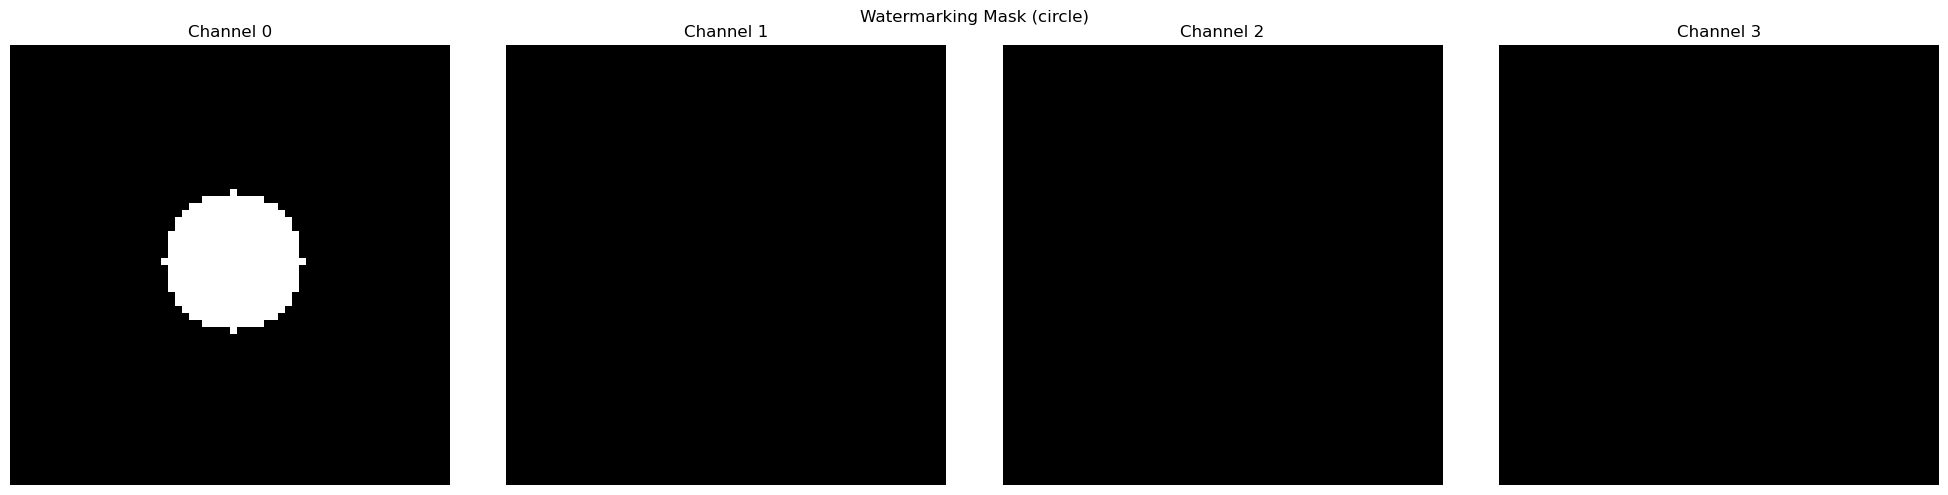

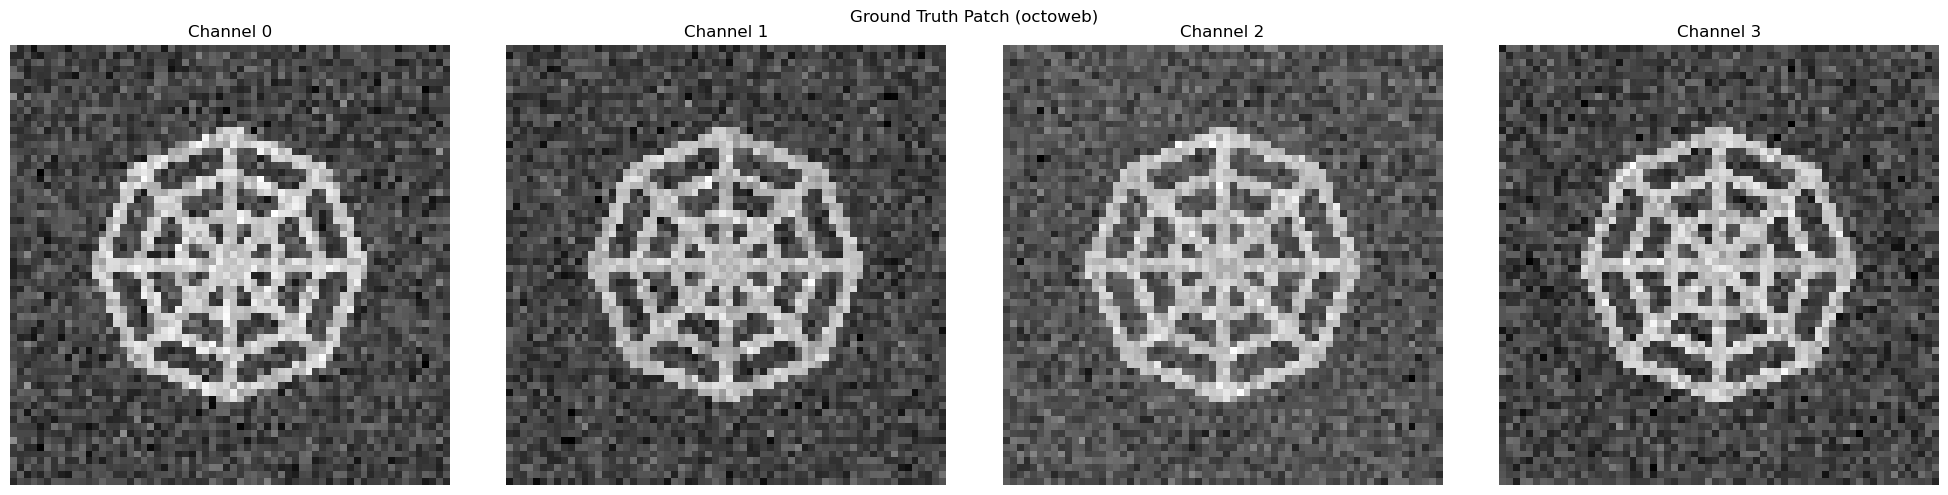

Using PNSRL1 wrapper for the model.
Loading checkpoint: verifier_dataset_stablediff_octoweb_verifier_200.pth
Restored model and optimizer. Resuming from epoch 157


In [1]:
# resume_fft_detector.py
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from ds import (
    WatermarkOnTheFlyDataset,
    discover_dataset_files,
    get_test_aug,
)
from attack import make_train_image_augmentations
from model import make_model
from engine import train_epoch, safe_eval_call, train_epoch_psnr, safe_eval_call_psnr_l1, train_epoch_psnr_l1, eval_model_psnr_l1
import time
from model import load_checkpoint
from datetime import timedelta
from watermark import get_watermarking_mask, get_watermarking_pattern
from utils.vis import visualise_noise
import warnings 
warnings.filterwarnings("ignore")

# ----------------- Config (adjust if needed) -----------------
DATA_DIR = "./verifier_dataset_stablediff_octoweb"
CHECKPOINT_PATH = "verifier_dataset_stablediff_octoweb_verifier_200.pth" # [ None, "fft_detector_ckpt_full.pth"]
BATCH_SIZE = 8
NUM_WORKERS = 0
TOTAL_NUM_EPOCHS = (
    300  # total epochs you want to reach (resume will continue until this)
)
LR = 2e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
VALIDATION_SPLIT = 0.15
NUM_INFERENCE_STEPS = 50
GUIDANCE_SCALE = 7.5
SAVE_EVERY_EPOCHS = 1  # how often to save full checkpoint
IMAGE_SIZE = 512  # might adjust to your pipeline / VAE size
IMG_AUG = make_train_image_augmentations(IMAGE_SIZE)
TEST_AUG = get_test_aug(IMAGE_SIZE)
INCLUDE_MASK_PATCH = (
    False  # whether to include watermark mask and gt_patch in model input
)
INCLUDE_PSNR_L1 = True  # whether to include PSNR and L1 metric in dataset output

# Watermarking parameters (should match those used during watermark embedding)
W_MASK_SHAPE = 'circle'
W_CHANNEL = 0
W_RADIUS = 10
W_STRENGTH = 0.99
W_PATTERN = 'octoweb'

CKPT_NAME = f"{DATA_DIR}_verifier_{TOTAL_NUM_EPOCHS}.pth"
# -------------------------------------------------------------

# ---------------- reproducibility ----------------
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
# -------------------------------------------------

# ---------------- Load or define PIPE and TEXT_EMBEDDINGS ----------------
# Validate that PIPE and TEXT_EMBEDDINGS are present (or load them here)
try:
    import torch
    import diffusers
    from diffusers import DPMSolverMultistepScheduler
    from inverse_stable_diffusion import InversableStableDiffusionPipeline

    model_id = "stabilityai/stable-diffusion-2-1-base"
    device = "cuda" if torch.cuda.is_available() else "cpu"
    scheduler = DPMSolverMultistepScheduler.from_pretrained(
        model_id, subfolder="scheduler"
    )
    pipe = InversableStableDiffusionPipeline.from_pretrained(
        model_id,
        scheduler=scheduler,
        torch_dtype=torch.float16,
        revision="fp16",
        verbose=False,
    )
    diffusers.utils.logging.disable_progress_bar()
    pipe.set_progress_bar_config(disable=True)
    pipe = pipe.to(device)

    TEXT_EMBEDDINGS = pipe.get_text_embedding("")  #
    PIPE = pipe  # make sure 'pipe' is in scope
except NameError:
    raise RuntimeError(
        "Please ensure `PIPE` and `TEXT_EMBEDDINGS` are available in the runtime before running resume script."
    )
# -----------------------------------------------------------------------

watermarking_mask = get_watermarking_mask(
        pipe.get_random_latents(),
        w_mask_shape=W_MASK_SHAPE,
        w_channel=W_CHANNEL,
        w_radius=W_RADIUS,
        device=device,
    )
visualise_noise(watermarking_mask[0], title=f"Watermarking Mask ({W_MASK_SHAPE})")
gt_patch = get_watermarking_pattern(
    pipe,
    w_seed=SEED,
    w_pattern=W_PATTERN,
    w_radius=W_RADIUS,
    device=device,
    strength=W_STRENGTH,
    shape=None,
)
visualise_noise(gt_patch[0], title=f"Ground Truth Patch ({W_PATTERN})")    

#  ---------------- Prepare datasets and dataloaders ----------------
file_paths, labels = discover_dataset_files(DATA_DIR)
combined = list(zip(file_paths, labels))
random.shuffle(combined)
file_paths, labels = zip(*combined)
n_val = int(len(file_paths) * VALIDATION_SPLIT)
val_paths = file_paths[:n_val]
val_labels = labels[:n_val]
train_paths = file_paths[n_val:]
train_labels = labels[n_val:]
train_ds = WatermarkOnTheFlyDataset(
    train_paths,
    train_labels,
    watermarking_mask=watermarking_mask,
    pipe=PIPE,
    text_embeddings=TEXT_EMBEDDINGS,
    num_inference_steps=NUM_INFERENCE_STEPS,
    guidance_scale=GUIDANCE_SCALE,
    device=DEVICE,
    image_aug=IMG_AUG,
    include_mask_patch=INCLUDE_MASK_PATCH,
    include_psnr_l1=INCLUDE_PSNR_L1,
    gt_patch=gt_patch,
    psnr_return_prob=False,
)
val_ds = WatermarkOnTheFlyDataset(
    val_paths,
    val_labels,
    pipe=PIPE,
    text_embeddings=TEXT_EMBEDDINGS,
    num_inference_steps=NUM_INFERENCE_STEPS,
    guidance_scale=GUIDANCE_SCALE,
    device=DEVICE,
    image_aug=IMG_AUG,
    include_mask_patch=INCLUDE_MASK_PATCH,
    include_psnr_l1=INCLUDE_PSNR_L1,
    watermarking_mask=watermarking_mask,
    gt_patch=gt_patch,
    psnr_return_prob=False,
)
val_ds_no_aug = WatermarkOnTheFlyDataset(
    val_paths,
    val_labels,
    pipe=PIPE,
    text_embeddings=TEXT_EMBEDDINGS,
    num_inference_steps=NUM_INFERENCE_STEPS,
    guidance_scale=GUIDANCE_SCALE,
    device=DEVICE,
    image_aug=None,
    include_mask_patch=INCLUDE_MASK_PATCH,
    include_psnr_l1=INCLUDE_PSNR_L1,
    watermarking_mask=watermarking_mask,
    gt_patch=gt_patch,
    psnr_return_prob=False,
)
# -------------------------------------------------------------------

# infer input channels from a sample (may be expensive, but needed to create model)
sample_fft = train_ds[0][0]  # first in the tuple
in_ch = sample_fft.shape[0]

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)
val_loader_no_aug = DataLoader(
    val_ds_no_aug, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)

# build model + optimizer + criterion
model = make_model(in_ch, include_psnr_l1=INCLUDE_PSNR_L1).to(DEVICE)
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
crit = nn.CrossEntropyLoss()

model.base_model, start_epoch, best_val_loss, best_epoch = load_checkpoint(
    model.base_model, CHECKPOINT_PATH, DEVICE, opt=opt
)


In [7]:
# training loop (resume) with pretty printing
total_start = time.time()

for epoch in range(start_epoch, TOTAL_NUM_EPOCHS + 1):
    epoch_start = time.time()
    print("=" * 80)
    print(
        f"Epoch {epoch:3d}/{TOTAL_NUM_EPOCHS:3d}    Time elapsed: {str(timedelta(seconds=int(time.time() - total_start)))}"
    )
    lr = opt.param_groups[0].get("lr", float("nan"))
    print(f"LR: {lr:.3e}")
    print("-" * 80)

    # train
    t0 = time.time()
    if INCLUDE_PSNR_L1:
        train_loss = train_epoch_psnr_l1(model, train_loader, opt, crit, device=DEVICE)
    else:
        train_loss = train_epoch(model, train_loader, opt, crit, device=DEVICE)
    t_train = time.time() - t0

    # validation (augmented) - informational
    if INCLUDE_PSNR_L1:
        acc_aug, auc_aug, val_loss_aug = safe_eval_call_psnr_l1(model, val_loader, crit, device)
        # validation (no aug) - primary criterion for saving
        acc_noaug, auc_noaug, val_loss_noaug = safe_eval_call_psnr_l1(model, val_loader_no_aug, crit, device)
    else:
        acc_aug, auc_aug, val_loss_aug = safe_eval_call(model, val_loader, crit, device)
        # validation (no aug) - primary criterion for saving
        acc_noaug, auc_noaug, val_loss_noaug = safe_eval_call(model, val_loader_no_aug, crit, device)

    epoch_time = time.time() - epoch_start

    # pretty table-like summary
    # widths
    col1_w = 20
    col_w = 18
    print(
        f"{'Metric':<{col1_w}} {'Train':>{col_w}} {'Val (AUG)':>{col_w}} {'Val (NO-AUG)':>{col_w}}"
    )
    print("-" * (col1_w + col_w * 3 + 6))

    # Loss row
    print(
        f"{'Loss':<{col1_w}} "
        f"{train_loss:>{col_w}.4f} "
        f"{(val_loss_aug if not (val_loss_aug!=val_loss_aug) else float('nan')):>{col_w}.4f} "
        f"{(val_loss_noaug if not (val_loss_noaug!=val_loss_noaug) else float('nan')):>{col_w}.4f}"
    )

    # Accuracy row
    print(
        f"{'Accuracy':<{col1_w}} "
        f"{'--':>{col_w}} "
        f"{acc_aug:>{col_w}.4f} "
        f"{acc_noaug:>{col_w}.4f}"
    )

    # AUROC row
    print(
        f"{'AUROC':<{col1_w}} "
        f"{'--':>{col_w}} "
        f"{auc_aug:>{col_w}.4f} "
        f"{auc_noaug:>{col_w}.4f}"
    )

    print("-" * (col1_w + col_w * 3 + 6))
    print(
        f"Epoch time: {epoch_time:.1f}s (train: {t_train:.1f}s). Cumulative: {str(timedelta(seconds=int(time.time() - total_start)))}"
    )
    if best_epoch is not None:
        print(f"Best no-aug val loss so far: {best_val_loss:.6f} (epoch {best_epoch})")
    else:
        print(
            f"Best no-aug val loss so far: {best_val_loss if best_val_loss!=float('inf') else 'N/A'}"
        )

    # decide saving based on no-aug validation loss
    try:
        current_val_loss = float(val_loss_noaug)
    except Exception:
        current_val_loss = float("inf")

    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss
        best_epoch = epoch
        ckpt_dict = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": opt.state_dict(),
            "best_val_loss": best_val_loss,
            "best_epoch": best_epoch,
        }
        torch.save(ckpt_dict, CKPT_NAME)
        print(
            f">>> Saved NEW BEST checkpoint: {CKPT_NAME} (best_val_loss={best_val_loss:.6f}, epoch={best_epoch})"
        )
    else:
        print(f"No improvement (current no-aug val loss {current_val_loss:.6f})")

    ckpt_dict = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": opt.state_dict(),
            "best_val_loss": best_val_loss,
            "best_epoch": best_epoch,
    }
    
torch.save(ckpt_dict, CKPT_NAME.replace(".pth", "_final.pth"))
print("=" * 80)
print("Training complete.")
print(f"Best no-aug val loss: {best_val_loss:.6f} (epoch {best_epoch})")

Epoch 157/300    Time elapsed: 0:00:00
LR: 2.000e-04
--------------------------------------------------------------------------------


Metric                            Train          Val (AUG)       Val (NO-AUG)
--------------------------------------------------------------------------------
Loss                             0.4783             0.5259             0.3388
Accuracy                             --             0.7800             0.9800
AUROC                                --             0.8381             0.9900
--------------------------------------------------------------------------------
Epoch time: 1284.5s (train: 956.7s). Cumulative: 0:21:24
Best no-aug val loss so far: 0.093368 (epoch 156)
No improvement (current no-aug val loss 0.338824)
Epoch 158/300    Time elapsed: 0:21:24
LR: 2.000e-04
--------------------------------------------------------------------------------


Metric                            Train          Val (AUG)       Val (NO-AUG)
--------------------------------------------------------------------------------
Loss                             0.4632             0.5293             0.3230
Accuracy                             --             0.7733             0.9533
AUROC                                --             0.8419             0.9909
--------------------------------------------------------------------------------
Epoch time: 1270.2s (train: 939.3s). Cumulative: 0:42:34
Best no-aug val loss so far: 0.093368 (epoch 156)
No improvement (current no-aug val loss 0.322970)
Epoch 159/300    Time elapsed: 0:42:34
LR: 2.000e-04
--------------------------------------------------------------------------------


Metric                            Train          Val (AUG)       Val (NO-AUG)
--------------------------------------------------------------------------------
Loss                             0.4253             0.4772             0.2916
Accuracy                             --             0.7933             0.9267
AUROC                                --             0.8777             0.9861
--------------------------------------------------------------------------------
Epoch time: 1263.6s (train: 934.2s). Cumulative: 1:03:38
Best no-aug val loss so far: 0.093368 (epoch 156)
No improvement (current no-aug val loss 0.291610)
Epoch 160/300    Time elapsed: 1:03:38
LR: 2.000e-04
--------------------------------------------------------------------------------


Metric                            Train          Val (AUG)       Val (NO-AUG)
--------------------------------------------------------------------------------
Loss                             0.4094             0.4330             0.2969
Accuracy                             --             0.8067             0.9067
AUROC                                --             0.8789             0.9852
--------------------------------------------------------------------------------
Epoch time: 1274.7s (train: 944.6s). Cumulative: 1:24:53
Best no-aug val loss so far: 0.093368 (epoch 156)
No improvement (current no-aug val loss 0.296874)
Epoch 161/300    Time elapsed: 1:24:53
LR: 2.000e-04
--------------------------------------------------------------------------------


...

Metric                            Train          Val (AUG)       Val (NO-AUG)
--------------------------------------------------------------------------------
Loss                             0.1906             0.3279             0.1852
Accuracy                             --             0.8800             0.9333
AUROC                                --             0.9401             0.9907
--------------------------------------------------------------------------------
Epoch time: 1436.0s (train: 1063.0s). Cumulative: 2 days, 4:57:29
Best no-aug val loss so far: 0.082489 (epoch 221)
No improvement (current no-aug val loss 0.185244)
Epoch 297/300    Time elapsed: 2 days, 4:57:29
LR: 2.000e-04
--------------------------------------------------------------------------------


Metric                            Train          Val (AUG)       Val (NO-AUG)
--------------------------------------------------------------------------------
Loss                             0.1840             0.4271             0.2979
Accuracy                             --             0.8133             0.8800
AUROC                                --             0.9201             0.9943
--------------------------------------------------------------------------------
Epoch time: 1489.6s (train: 1094.0s). Cumulative: 2 days, 5:22:19
Best no-aug val loss so far: 0.082489 (epoch 221)
No improvement (current no-aug val loss 0.297934)
Epoch 298/300    Time elapsed: 2 days, 5:22:19
LR: 2.000e-04
--------------------------------------------------------------------------------


Metric                            Train          Val (AUG)       Val (NO-AUG)
--------------------------------------------------------------------------------
Loss                             0.2252             0.3170             0.1840
Accuracy                             --             0.8600             0.9267
AUROC                                --             0.9356             0.9936
--------------------------------------------------------------------------------
Epoch time: 1489.4s (train: 1099.0s). Cumulative: 2 days, 5:47:09
Best no-aug val loss so far: 0.082489 (epoch 221)
No improvement (current no-aug val loss 0.184036)
Epoch 299/300    Time elapsed: 2 days, 5:47:09
LR: 2.000e-04
--------------------------------------------------------------------------------


Metric                            Train          Val (AUG)       Val (NO-AUG)
--------------------------------------------------------------------------------
Loss                             0.1806             0.3894             0.1909
Accuracy                             --             0.8333             0.9267
AUROC                                --             0.9084             0.9954
--------------------------------------------------------------------------------
Epoch time: 1515.0s (train: 1117.1s). Cumulative: 2 days, 6:12:24
Best no-aug val loss so far: 0.082489 (epoch 221)
No improvement (current no-aug val loss 0.190892)
Epoch 300/300    Time elapsed: 2 days, 6:12:24
LR: 2.000e-04
--------------------------------------------------------------------------------


Metric                            Train          Val (AUG)       Val (NO-AUG)
--------------------------------------------------------------------------------
Loss                             0.1978             0.3277             0.1536
Accuracy                             --             0.8733             0.9467
AUROC                                --             0.9437             0.9904
--------------------------------------------------------------------------------
Epoch time: 1419.8s (train: 1058.0s). Cumulative: 2 days, 6:36:03
Best no-aug val loss so far: 0.082489 (epoch 221)
No improvement (current no-aug val loss 0.153593)
Training complete.
Best no-aug val loss: 0.082489 (epoch 221)


'./verifier_dataset_stablediff_octoweb_verifier_300_final.pth'